# Center contrast-reversing grating analysis

This notebook analyzes `spotWithAnnularContrastReversingGrating` with the grating over the **center**. It follows the current flashed center/surround workflow: unrestricted discovery, amplifier-based recording-mode validation, explicit condition splitting, one-cell analysis, condition-specific HDF5 persistence, population F1/F2 summaries, and a recorded-stimulus schematic.

Fixed NDF filters and the protected numeric FilterWheel value remain separate. Bright-bar contrast and bar width are saved independently by default. `temporalFrequency` is the only additional condition dimension: interleaved frequencies are separated using each epoch's recorded `currentTemporalFrequency` before F1/F2 analysis and persistence.


In [1]:
import sys
import time

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        f'This notebook requires the retinanalysis Python 3.11 kernel; '
        f'got Python {sys.version.split()[0]} at {sys.executable}')

import_started = time.perf_counter()
import numpy as np
import pandas as pd
from IPython.display import display

import retinanalysis as ra
from retinanalysis.SCutils import explore as sc
from retinanalysis.SCutils.protocols import spot_annular_crg as crg

SITE = 'center'
SITE_LABEL = 'Center contrast-reversing grating analysis'
MAX_SERIES_RESISTANCE = 30e6
STORE_PATH = crg.store_dir() / f'{SITE}_grating'

print(f'Python {sys.version.split()[0]} | {sys.executable}')
print(f'Imports ready in {time.perf_counter() - import_started:.2f} s')
print(f'Saved records: {STORE_PATH}')


Python 3.11.13 | /Users/chrischen/opt/anaconda3/envs/retinanalysis/bin/python
Imports ready in 0.48 s
Saved records: /Volumes/ChrisNewSSD/retinanalysis_output/spot_annular_crg/center_grating


## 1. Load or refresh the single-cell database

Leave `UPDATE_DATABASE = False` for normal analysis. Set it to `True` only when mounted experiment files have changed.


In [2]:
UPDATE_DATABASE = False
ra.djconnect()

if UPDATE_DATABASE:
    database_report = ra.populate_database()
    print(f"newly added: {len(database_report['added'])}")
    print(f"refreshed: {len(database_report['updated'])}")
    print(f"errored: {len(database_report['skipped'])}")
else:
    print('Connected to the existing database. Set UPDATE_DATABASE=True to ingest changes.')


Connected to the existing database. Set UPDATE_DATABASE=True to ingest changes.


## 2. Search the database for center recordings

Discovery retains every cell type, FilterWheel value, bright contrast, bar width, temporal frequency, and epoch count. Each row is one explicit site × mode × light path × background × bright contrast × bar width × temporal-frequency condition. A historical block with conflicting protected wheel readings remains visible with `FilterWheel=NaN` and an explicit conflict status; no arbitrary wheel value is chosen.


In [3]:
protocol_index = sc.find_blocks(crg.PROTOCOL, show=False)
protocol_dates = sorted(protocol_index.exp_name.dropna().unique())
date_index_map = {name: index + 1 for index, name in enumerate(protocol_dates)}

blocks = crg.find_blocks(show=False)
blocks = crg.check_series_resistance(
    blocks, max_series_resistance=MAX_SERIES_RESISTANCE)
site_blocks = blocks[blocks.grating_site.eq(SITE)].copy()

selected = crg.group_blocks(
    site_blocks, show=False,
    require_filter_wheel=False,
    allowed_bright_contrast=None,
    allowed_temporal_frequency=None,
    min_bar_width=None,
    min_epochs=None,
    separate_bright_contrast=True,
    collapse_bar_widths=False)
selected = selected.sort_values(
    ['exp_name', 'cell_label', 'onlineAnalysis', 'ndf_combination',
     'backgroundIntensity', 'bright', 'bar_width', 'temporalFrequency']
).reset_index(drop=True)
selected.insert(0, 'date_index', selected.exp_name.map(date_index_map).astype(int))

print(f'{SITE_LABEL}: {len(selected)} conditions across '
      f'{selected.exp_name.nunique()} experiments and '
      f"{selected.groupby(['exp_name', 'cell_label']).ngroups} cells")
condition_columns = [
    'date_index', 'exp_name', 'cell_label', 'cell_type_short', 'onlineAnalysis',
    'ndf_combination', 'filter_wheel_ndf', 'max_light_level',
    'backgroundIntensity', 'bright', 'bar_width', 'temporalFrequency',
    'spot_intensity', 'aperture', 'annulus_inner', 'annulus_outer',
    'blocks', 'epochs',
]
condition_columns = [column for column in condition_columns if column in selected]
sc.scroll_table(
    selected[condition_columns], height=430,
    num_cols=('date_index', 'filter_wheel_ndf', 'max_light_level',
              'backgroundIntensity', 'bright', 'bar_width',
              'temporalFrequency', 'spot_intensity', 'aperture',
              'annulus_inner', 'annulus_outer', 'blocks', 'epochs'))


reading the trace for 1 block(s) whose mode the label does not settle (0 never labelled, 1 contradicted)
series resistance read for 107/107 blocks

onlineAnalysis vs the amplifier (as recorded, before any relabelling)
series resistance says  cell-attached  whole-cell
onlineAnalysis says                              
cell-attached                      89           0
whole-cell                          1          17

1 block(s) where the amplifier disagrees:
    exp_name cell_label cell_type_short recorded   analyzed as  Rs (MOhm)  n_epochs  block_id                                                                                   rs_flag
2026-05-06_E      Cell3         bipolar      exc extracellular        0.0        19     36399 relabelled 'exc' -> 'extracellular': series resistance is 0 and the trace contains spikes

1 block(s) relabelled; they are analyzed as the amplifier says, and their recorded label is kept in onlineAnalysis_recorded
Center contrast-reversing grating analysis: 55

date_index,exp_name,cell_label,cell_type_short,onlineAnalysis,ndf_combination,filter_wheel_ndf,max_light_level,backgroundIntensity,bright,bar_width,temporalFrequency,spot_intensity,aperture,annulus_inner,annulus_outer,blocks,epochs
1,2026-04-23_E,Cell1,OFF-parasol,extracellular,EL3 + FW0,0.0,30000.0,0.5,0.9,150.0,4.0,0.05,0.0,0.0,500.0,2,36
1,2026-04-23_E,Cell1,OFF-parasol,extracellular,EL3 + FW1,1.0,3000.0,0.5,0.9,150.0,4.0,0.05,0.0,0.0,500.0,1,22
1,2026-04-23_E,Cell2,OFF-parasol,extracellular,EL3 + FW0,0.0,30000.0,0.5,0.9,75.0,4.0,0.05,0.0,0.0,500.0,1,12
1,2026-04-23_E,Cell2,OFF-parasol,extracellular,EL3 + FW1,1.0,3000.0,0.5,0.9,75.0,4.0,0.05,0.0,0.0,500.0,1,11
1,2026-04-23_E,Cell3,horizontal,extracellular,EL3 + FW0,0.0,30000.0,0.5,0.9,150.0,4.0,0.05,0.0,0.0,500.0,1,14
1,2026-04-23_E,Cell3,horizontal,extracellular,EL3 + FW1,1.0,3000.0,0.5,0.9,150.0,4.0,0.05,0.0,0.0,500.0,1,22
1,2026-04-23_E,Cell4,horizontal,extracellular,EL3 + FW0,0.0,30000.0,0.5,0.9,150.0,4.0,0.05,0.0,0.0,500.0,2,34
1,2026-04-23_E,Cell4,horizontal,extracellular,EL3 + FW1,1.0,3000.0,0.5,0.9,150.0,4.0,0.05,0.0,0.0,500.0,1,22
1,2026-04-23_E,Cell6,OFF-parasol,extracellular,EL3 + FW0,0.0,30000.0,0.5,0.9,100.0,4.0,0.05,0.0,0.0,500.0,2,25
1,2026-04-23_E,Cell6,OFF-parasol,extracellular,EL3 + FW1,1.0,3000.0,0.5,0.9,100.0,4.0,0.05,0.0,0.0,500.0,1,22


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:430px"><table><thead><tr><th>date_index</th><th>exp_name</th><th>cell_label</th><th>cell_type_short</th><th>onlineAnalysis</th><th>ndf_combination</th><th>filter_wheel_ndf</th><th>max_light_level</th><th>backgroundIntensity</th><th>bright</th><th

## 3. Analyze one cell across every recorded condition

The three controls below select a live date/cell/mode combination. Conditions remain separate by fixed-NDF path, numeric FilterWheel, background, bright contrast, bar width, and temporal frequency. `COLLAPSE_BAR_WIDTHS=True` is the only switch that deliberately pools widths; temporal frequencies are always separate.

The reversing analysis reports the response folded over one reversal cycle plus F1 and F2 amplitudes. When more than one light level is present, it also creates a separate F2 overlay in which each curve is divided by its own maximum response. Offsets are currently expressed in amplifier samples to preserve the established reversing-grating analysis contract.


ALERT: 2 unique conditions found; each will be analyzed separately:


,condition_index,ndf_combination,filter_wheel_ndf,backgroundIntensity,bright,bar_width,temporalFrequency,max_light_level,rstar,blocks,epochs,block_ids
0,1,EL3 + FW0,0.0,0.5,0.9,150,4.0,30000.0,15000.0,2,36,"34330, 34334"
1,2,EL3 + FW1,1.0,0.5,0.9,150,4.0,3000.0,1500.0,1,22,34333


Condition 1/2 metadata:


,condition_index,cell_label,cell_type,onlineAnalysis,spotIntensity,brightBarContrast,barWidth_um,temporalFrequency_Hz,apertureDiameter_um,annulusInnerDiameter_um,annulusOuterDiameter_um,background_Rstar_per_s,block_ids,epochs
0,1,Cell1,OFF-parasol,extracellular,0.05,0.9,150,4.0,0.0,0.0,500.0,15000.0,"34330, 34334",36


2026-04-23_E | RGC\OFF-parasol | Cell1 | extracellular | grating center | 4 Hz | FW=0.0 bg=0.50 (15000R*) | 36 epochs
  dark contrasts   : [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
  phase A - B      : [1.998 3.529 4.255 5.016 5.747 5.278 4.291 5.564 2.245 1.07  0.137]
  F1 / F2          : [9.18 8.93 8.89 8.27 8.92 9.16 6.56 5.36 2.36 1.67 0.23] / [45.12 45.98 44.51 42.6  42.35 39.69 33.1  20.1   5.14  3.6   2.74]
  null nearest=0.000 interp=nan | cone pred=-0.348
Condition 2/2 metadata:


,condition_index,cell_label,cell_type,onlineAnalysis,spotIntensity,brightBarContrast,barWidth_um,temporalFrequency_Hz,apertureDiameter_um,annulusInnerDiameter_um,annulusOuterDiameter_um,background_Rstar_per_s,block_ids,epochs
0,2,Cell1,OFF-parasol,extracellular,0.05,0.9,150,4.0,0.0,0.0,500.0,1500.0,34333,22


2026-04-23_E | RGC\OFF-parasol | Cell1 | extracellular | grating center | 4 Hz | FW=1.0 bg=0.50 (2000R*) | 22 epochs
  dark contrasts   : [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
  phase A - B      : [-6.815  0.522 -5.418 -5.169 -3.324 -3.004 -2.671 -0.753  0.521 -0.436
  5.126]
  F1 / F2          : [14.32 12.19 12.32 11.76 12.16 10.87 11.79 11.7  11.95 13.94 12.82] / [39.99 40.07 38.35 37.63 36.92 36.47 33.81 32.1  31.47 27.8  24.16]
  null nearest=-0.100 interp=-0.907 | cone pred=-0.508
Analyzed 2 separate condition(s) for 2026-04-23_E Cell1.


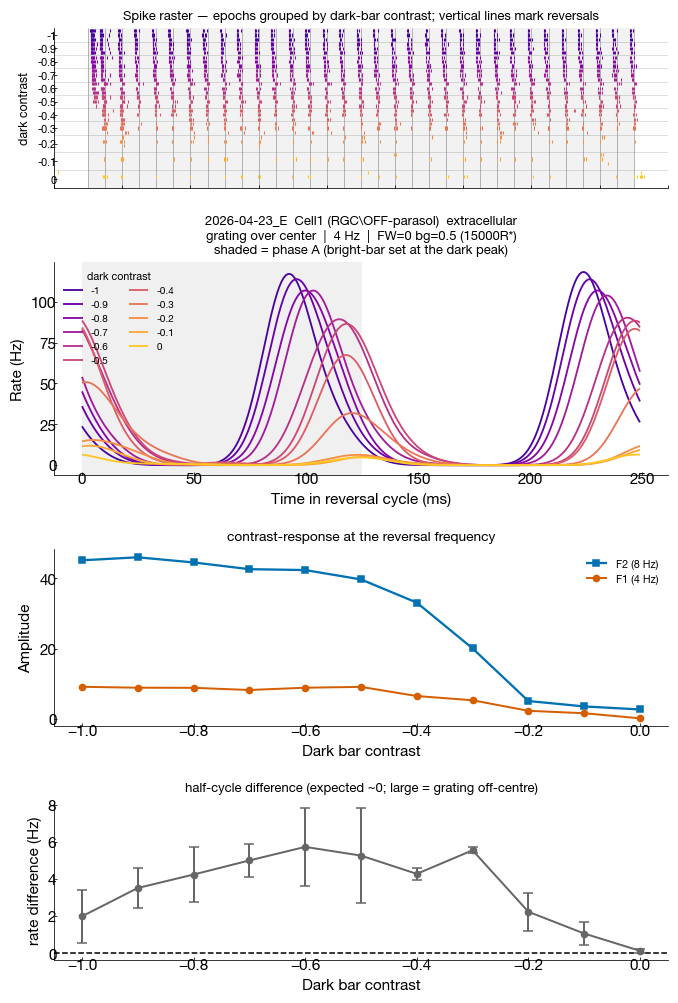

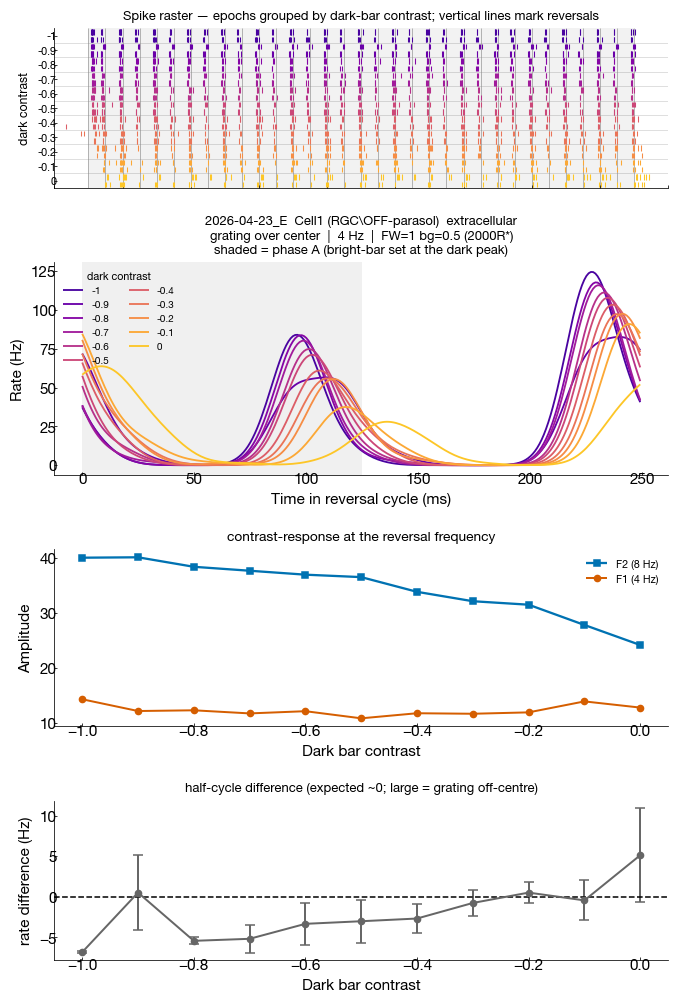

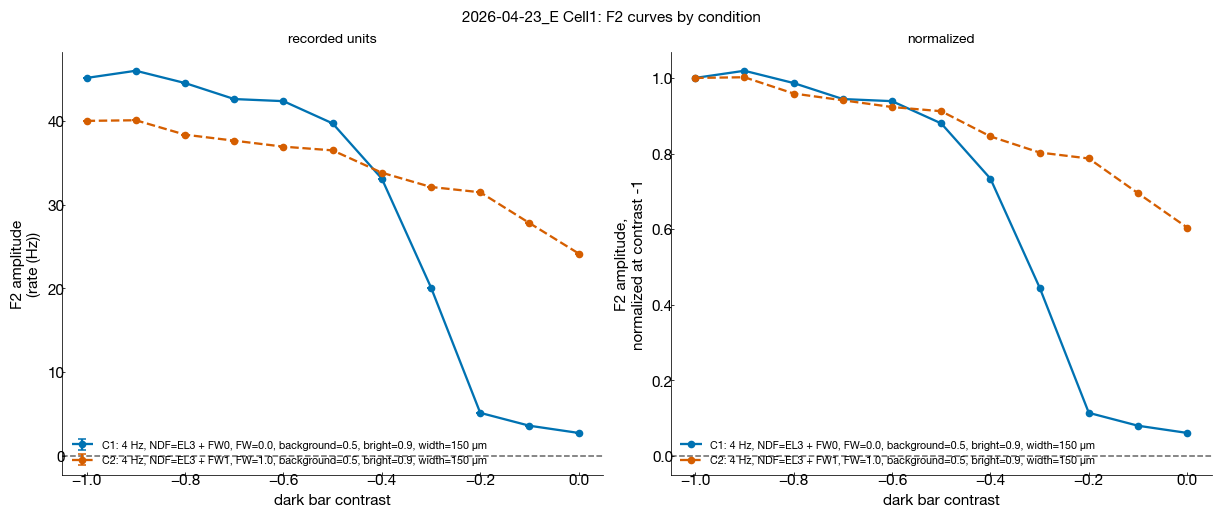

In [2]:
# Standalone after the import cell; Section 2 is optional.
DATE_INDEX = 1
CELL_LABEL = 'Cell1'
ONLINE_ANALYSIS = 'extracellular'  # 'extracellular', 'exc', or 'inh'
COLLAPSE_BAR_WIDTHS = True
SPIKE_OFFSET_SAMPLES = 30
WC_OFFSET_SAMPLES = 50
DETECTOR_KWARGS = {
    'min_peak_amplitude': 10.0,
    'max_trial_length_s': 5.0,
    'cluster_across_trials': True,
    'global_polarity': True,
}

section3 = crg.analyze_cell_conditions(
    date_index=DATE_INDEX,
    cell_label=CELL_LABEL,
    online_analysis=ONLINE_ANALYSIS,
    site=SITE,
    collapse_bar_widths=COLLAPSE_BAR_WIDTHS,
    max_series_resistance=MAX_SERIES_RESISTANCE,
    spike_offset=SPIKE_OFFSET_SAMPLES,
    wc_offset=WC_OFFSET_SAMPLES,
    detector_kwargs=DETECTOR_KWARGS,
    keep_raw=True,
    plot=True,
    show=True)

EXP_NAME = section3.exp_name
condition_rows = section3.condition_rows
light_conditions = section3.light_conditions
records = section3.records
condition_figures = section3.condition_figures
condition_overlay_figure = section3.light_tuning_figure
max_normalized_light_figure = section3.max_normalized_light_figure


### 3a. Check spike detection on a random subset of epochs

Enable this after Section 3 to inspect raw traces and detected spikes. Sampling is reproducible and occurs independently within every saved condition, including temporal frequency.


In [ ]:
RUN_SPIKE_DETECTION_QC = False
SPIKE_QC_FRACTION = 0.30
SPIKE_QC_RANDOM_SEED = 0
SPIKE_QC_EPOCHS_PER_VIEW = 1

if RUN_SPIKE_DETECTION_QC and not records:
    raise ValueError('Run Section 3 before checking spike detection')

spike_qc_datasets = []
for condition_index, record in enumerate(
        records if RUN_SPIKE_DETECTION_QC else [], start=1):
    if record.online_analysis != 'extracellular':
        continue
    if record.raw is None or not record.raw.get('traces'):
        print(f'Condition {condition_index}: no raw traces; rerun Section 3 with keep_raw=True.')
        continue
    spike_qc_datasets.append({
        'label': f'Condition {condition_index}: {record.temporal_frequency:g} Hz',
        'title': (f'Condition {condition_index}: {record.exp_name} | '
                  f'{record.cell_label} | {record.temporal_frequency:g} Hz | '
                  f'{record.config.get("ndf_combination", "")}'),
        'traces': record.raw['traces'],
        'spike_times': record.raw['spike_times_ms'],
        'sample_rate': record.raw['sample_rate'],
        'spike_time_unit': 'ms',
        'stimulus_window_ms': (
            record.pre_time_ms, record.pre_time_ms + record.stim_time_ms),
        'source_group': record.exp_name,
        'block_ids': record.raw.get('block_id'),
    })

if not RUN_SPIKE_DETECTION_QC:
    print('Spike-detection QC skipped. Set RUN_SPIKE_DETECTION_QC = True to enable it.')
    spike_detection_qc = None
elif not spike_qc_datasets:
    print('No extracellular records are available for spike-detection QC.')
    spike_detection_qc = None
else:
    spike_detection_qc = ra.spike_detection_qc_browser(
        spike_qc_datasets, fraction=SPIKE_QC_FRACTION,
        random_state=SPIKE_QC_RANDOM_SEED,
        epochs_per_view=SPIKE_QC_EPOCHS_PER_VIEW)


### 3b. Save these conditions

Each HDF5 group is keyed by the flashed-grating condition dimensions plus temporal frequency. The scalar summary and HDF5 attributes both retain `temporal_frequency`; `cfg_temporalFrequency` records the protocol metadata value.


In [ ]:
if not records:
    raise ValueError('Run Section 3 before saving')
condition_output_path = crg.save_records(records, path=STORE_PATH)
print(f'Saved {len(records)} separate condition(s) to {condition_output_path}')


### 3c. Check saved conditions

The table keeps one row per site/light/bright/bar-width/temporal-frequency condition.


In [ ]:
saved_conditions = crg.load_summary(path=STORE_PATH)
saved_columns = [
    'exp_name', 'cell_label', 'cell_type', 'online_analysis', 'grating_site',
    'temporal_frequency', 'ndf_combination', 'max_light_level',
    'background_intensity', 'bright_bar_contrast', 'bar_widths', 'rstar',
    'n_epochs', 'block_ids',
]
saved_columns = [column for column in saved_columns if column in saved_conditions]
print(f'{len(saved_conditions)} saved {SITE} reversing-grating condition(s)')
sc.scroll_table(
    saved_conditions[saved_columns], height=320,
    num_cols=('temporal_frequency', 'max_light_level',
              'background_intensity', 'bright_bar_contrast', 'rstar', 'n_epochs'))


## 4. Population F1/F2 contrast-response

Population analysis retains temporal frequency as a panel dimension. Controls may restrict mode, bright contrast, or frequency, but no restriction occurs during discovery or saving. The raw figure uses recorded units; the normalized figure divides each cell by its own peak harmonic amplitude before averaging, so repeated records from one cell do not gain extra weight.


In [ ]:
POPULATION_MODE = 'extracellular'
POPULATION_BRIGHT_CONTRAST = 0.9
POPULATION_TEMPORAL_FREQUENCIES = None  # e.g. (2.0, 4.0), or None for all
POPULATION_HARMONIC = 'f2'

summary = crg.add_condition(crg.load_summary(path=STORE_PATH))
if summary.empty:
    raise ValueError(f'No saved {SITE} reversing-grating records in {STORE_PATH}')

population_summary = summary[
    summary.online_analysis.eq(POPULATION_MODE)
    & np.isclose(summary.bright_bar_contrast, POPULATION_BRIGHT_CONTRAST)
].copy()
if POPULATION_TEMPORAL_FREQUENCIES is not None:
    population_summary = population_summary[
        population_summary.temporal_frequency.isin(
            list(POPULATION_TEMPORAL_FREQUENCIES))].copy()
if population_summary.empty:
    raise ValueError('No saved records matched the requested population controls')

population_summary['cell_id'] = (
    population_summary.exp_name.astype(str) + '/'
    + population_summary.cell_label.astype(str))
population_table = (population_summary.groupby(
    ['temporal_frequency', 'rstar_level'], dropna=False)
    .agg(records=('key', 'size'), cells=('cell_id', 'nunique'),
         epochs=('n_epochs', 'sum'), min_rstar=('rstar', 'min'),
         max_rstar=('rstar', 'max')).reset_index())
sc.scroll_table(
    population_table, height=220,
    num_cols=('temporal_frequency', 'rstar_level', 'records', 'cells',
              'epochs', 'min_rstar', 'max_rstar'))

population_records = crg.load_records(
    population_summary.key.tolist(), path=STORE_PATH)
population_raw_figure = crg.plot_population_contrast_response(
    population_summary, records=population_records,
    harmonic=POPULATION_HARMONIC, normalize=False, min_cells=1)
population_normalized_figure = crg.plot_population_contrast_response(
    population_summary, records=population_records,
    harmonic=POPULATION_HARMONIC, normalize=True, min_cells=2)


## 5. Example center contrast-reversing stimulus

Render the two recorded half-cycle frames and the square-wave reversal timing. The selected epoch is matched to the saved record's temporal frequency.


In [ ]:
EXAMPLE_CONDITION_INDEX = 1
if not 1 <= EXAMPLE_CONDITION_INDEX <= len(records):
    raise ValueError(f'EXAMPLE_CONDITION_INDEX must be 1-{len(records)}')
example_record = records[EXAMPLE_CONDITION_INDEX - 1]
example_block = int(example_record.block_ids[0])
stim = ra.StimBlock(example_record.exp_name, example_block, verbose=False)
epoch_frequencies = stim.df_epochs.apply(
    lambda row: row.get('currentTemporalFrequency',
                        row.epoch_parameters.get('currentTemporalFrequency', np.nan)),
    axis=1)
matching_epochs = stim.df_epochs[np.isclose(
    pd.to_numeric(epoch_frequencies, errors='coerce'),
    example_record.temporal_frequency)]
if matching_epochs.empty:
    raise ValueError('No epoch matches the saved temporal frequency')
example_parameters = matching_epochs.epoch_parameters.iloc[0]
stimulus_figure = crg.plot_stimulus_schematic(example_parameters)
